# Intro to NumPy & Linear Algebra — Follow-Along

## Try me
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ffraile/computer_science_tutorials/blob/main/source/Applied%20Mathematics/class%20notes/Intro_to_NumPy_and_Linear_Algebra_follow_along.ipynb)[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ffraile/computer_science_tutorials/main?labpath=source%2FApplied%20Mathematics%2Fclass%20notes%2FIntro_to_NumPy_and_Linear_Algebra_follow_along.ipynb)

This notebook blends **NumPy basics** with **Linear Algebra in NumPy**.
Use the **predict → run** habit: mentally predict outputs, then execute to check.


## 0) Setup
Import NumPy and create a random generator for reproducibility.

In [1]:

import numpy as np

## Introduction
### Motivation
- AI and machine learning combine statistics and mostly linear algebra
- **Key enabler** efficient and scalable linear algebra operations with large data
- Bridge the gap between mathematical language and programming languages

### Objectives
- Understand the mathematical engine that drives so much of modern tech: Array programming
- Bypass (slow and computationally inefficient) basic for loops.
- Do so through the lens of linear algebra
- Find links between mathematical modeling and programming


### Intro for Non-Programmers (I)
- Numpy: Python holy grail for **array programming**
- Array programming let us bypass for loops and implement faster operations with Matrices and vectors
- Basic terminology:

    - A simple list of numbers, mathematically is just a vector. In numpy, we call it a **1D** array, it has exactly an axis, or dimension.
    - If you have something like a spreadsheet, a table, mathematically, we call it a matrix. In Numpy, we call it a **2D** array, it has two axis or dimensions
    - Dimensions are called axis: We can have an arbitrary number of dimensions or axis in a Numpy array
    - The **rank** tells us the number of dimensions. The **shape**, the number of elements


### Intro for Non-Programmers (II)
- Think of a color image, with width, height, and 3 color channels.
- We can fit the data into an array of rank 3: Height, width, and color
- The shape is 300x451x3 (300x451 image times 3 colors)

(300, 451, 3)


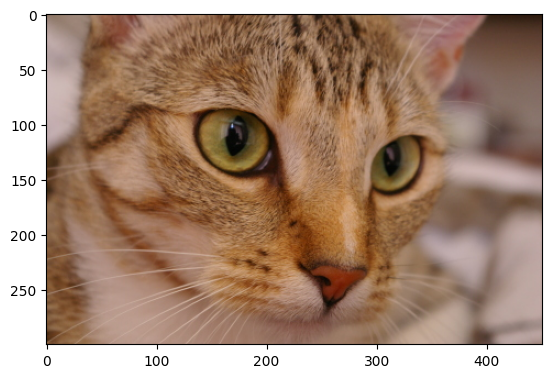

In [2]:
from skimage import data
from matplotlib import pyplot as plt
cat = data.chelsea()
plt.imshow(cat)
print(cat.shape)

### Intro for Non-Programmers (II)
- We can get a color channel for instance just by slicing the image.

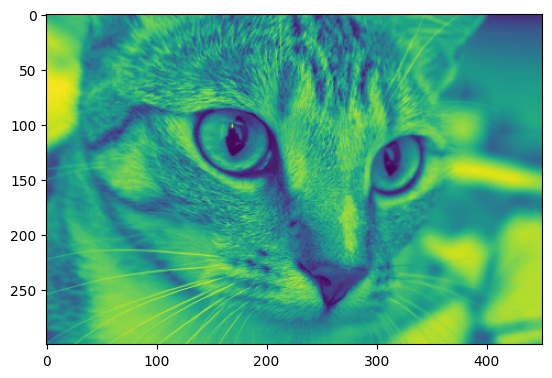

In [3]:
plt.imshow(cat[:,:,1]) # Only Green

## Agenda
- Intro 25 minutes
- Numpy basics 30 minutes
- Linear algebra 30 minutes

# Part A — NumPy Basics

Core concepts: creation, shapes/dtypes, indexing & slicing, boolean masks, broadcasting, vectorized ops, aggregations.

## Key ideas
- **Numpy arrays**: multidimensional, fixed-type containers for numbers.
- **Array programming**: think in terms of whole arrays, not elementwise loops.


### A1) Creating arrays
- From Python objects: ```np.array([1,2,3])```
- Ranges/grids: ```np.arange```, ```np.linspace```
- Filled arrays: ```np.zeros```, ```np.ones```, ```np.full```, ```np.eye```
- Random: ```random.int```, ```random.normal```
- ```dtype``` used to force or read the type

In [4]:

a = np.array([1, 2, 3])
b = np.arange(0, 10, 2)        # step range
c = np.linspace(0, 1, 5)       # 5 points in [0,1]
Z = np.zeros((2,3))
O = np.ones((3,2))
F = np.full((2,2), 7.5)
I = np.eye(3)
R = np.random.normal(loc=0, scale=1, size=(3,2))  # Random values with normal distribution

print("a:", a, a.dtype)
print("b:", b)
print("c:", c)
print("Z:\n", Z)
print("I:\n", I)
print("R:\n", R)

a: [1 2 3] int64
b: [0 2 4 6 8]
c: [0.   0.25 0.5  0.75 1.  ]
Z:
 [[0. 0. 0.]
 [0. 0. 0.]]
I:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
R:
 [[ 0.21647229 -1.00414296]
 [ 0.14917009 -1.82099297]
 [-0.91626809  0.70258613]]


In [ ]:
# Challenge. np.random.randint(low,high,shape) creates a numpy array of any shape with values from low to high. For instance, np.random.randint(0,5, (2,3)) creates a numpy array of shape 2x3 with values between 0 and 5.
# Use this info to create an array of size 128x128 with random bits

In [ ]:
# Challenge. Look at the cat example in the introduction. Use the function random to create an image of the same size as cat, but with random values drawn from a normal distribution, and then plot it.

### A2) Shape, dtype, size
- `.shape`, `.ndim`, `.size`, `.dtype`, `.itemsize`
- `astype` converts dtype

In [5]:

M = np.random.normal(0, 100, size=(3,4))
print("shape:", M.shape, "| ndim:", M.ndim, "| size:", M.size)
print("dtype:", M.dtype, "| itemsize:", M.itemsize, "bytes")
print("astype float32:\n", M.astype(np.float32))

shape: (3, 4) | ndim: 2 | size: 12
dtype: float64 | itemsize: 8 bytes
astype float32:
 [[ -87.16807   136.74026   177.31474  -174.9163  ]
 [ -28.215887   97.507545   -7.764087   64.47249 ]
 [-131.9176   -162.41922   219.6428     85.892395]]


### A3) Indexing, slicing, boolean masks
- 1D: `x[i]`, `x[i:j:k]`
- 2D: `A[i, j]`, `A[i, j1:j2]`, row/col slices
- Masks: `mask = (A % 2 == 0)` → `A[mask]`

In [6]:

x = np.arange(10)
A = np.random.normal(0, 20, size=(4,5))
print("x:", x)
print("x[2:8:2]:", x[2:8:2])
print("A:\n", A)
print("A[1, :]:", A[1, :])
print("A[:, 2]:", A[:, 2])

mask = (A > 10)
print("mask as 0/1:\n", mask.astype(int))
print("A[mask]:", A[mask])

x: [0 1 2 3 4 5 6 7 8 9]
x[2:8:2]: [2 4 6]
A:
 [[ 40.29040845  11.2099828   12.6670429  -19.53236574  24.9790349 ]
 [ -1.32035248  -5.32789079  -0.6299237    4.87824025 -15.86258631]
 [-20.80897509  28.79256532   3.99200466   6.43368619  -7.87346429]
 [-12.4336586   -4.08926711  19.30743726  12.50232581   5.03352625]]
A[1, :]: [ -1.32035248  -5.32789079  -0.6299237    4.87824025 -15.86258631]
A[:, 2]: [12.6670429  -0.6299237   3.99200466 19.30743726]
mask as 0/1:
 [[1 1 1 0 1]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 1 0]]
A[mask]: [40.29040845 11.2099828  12.6670429  24.9790349  28.79256532 19.30743726
 12.50232581]


In [7]:
# Mini challenge
# Print the two first rows of A

# Use a mask to find the values of A that are lower than 0

### A4) Broadcasting
- Fancy word, just extends a constant or array so that it matches the shape of another array
- Align shapes **from the right**; dims are compatible if equal or either is `1`.

In [8]:

B = np.ones((3,4))
row = np.array([1, 0, -1, 2])     # shape (4,)
col = np.array([[10],[20],[30]])  # shape (3,1)

print("B:\n", B)
print("B + row:\n", B + row)   # across rows
print("B + col:\n", B + col)   # down columns

B:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
B + row:
 [[2. 1. 0. 3.]
 [2. 1. 0. 3.]
 [2. 1. 0. 3.]]
B + col:
 [[11. 11. 11. 11.]
 [21. 21. 21. 21.]
 [31. 31. 31. 31.]]


In [ ]:
# Mini challenge: Assume the array below contains the prices of products of a portfolio. Each row represents a country and each column a product
prices = np.random.normal(2, 5, size=(30,40))
# Use broadcasting to add a flat 1 euro export tariff to your prices.

### A5) Vectorized ops, ufuncs, aggregations
- Elementwise: `+ - * / **`
- Ufuncs: `np.sqrt`, `np.exp`, `np.clip`, `np.where`
- Aggregations: `np.sum`, `np.mean`, `np.std` with `axis=`
- axis determines in which dimension or axis the operation will be performed.
- These are much more efficient than for loops!

In [11]:

X = np.linspace(-2, 2, 5)
print("X:", X)
print("X**2:", X**2)
print("sqrt(abs(X)):", np.sqrt(np.abs(X)))
print("where(X>=0, 1, -1):", np.where(X>=0, 1, -1))

G = np.random.randint(0,5, (2,3))
print("G:\n", G)
print("sum all:", np.sum(G))
print("mean per col:", np.mean(G, axis=0))
print("std per row:", np.std(G, axis=1))

X: [-2. -1.  0.  1.  2.]
X**2: [4. 1. 0. 1. 4.]
sqrt(abs(X)): [1.41421356 1.         0.         1.         1.41421356]
where(X>=0, 1, -1): [-1 -1  1  1  1]
G:
 [[4 2 4]
 [0 3 1]]
sum all: 14
mean per col: [2.  2.5 2.5]
std per row: [0.94280904 1.24721913]


In [ ]:
# Mini challenge.
# do the sum in each axis (with axis = 0, axis = 1, and axis = 2) in the following numpy array to understand the axis
axis_test = np.ones((2,3,4))
print("axis_test:\n", axis_test)
print("sum in axis 0:\n", axis_test.sum(axis=0))
## TODO: Complete and do the sum in the other two axis. Analyse the results

### A-PI Cards (predict; then run the check cell)

**Card A1 — Slicing vs copying**
```python
A = np.arange(9).reshape(3,3)
B = A[0, :]      # view or copy?
B[0] = 99
```
What changes in `A`?

In [ ]:

A = np.arange(9).reshape(3,3)
B = A[0, :]
B[0] = 99
print("A:\n", A)

**Card A2 — Mask + broadcasting**
```python
X = np.array([[-1,0,1],[2,-2,3]])
X[X<0] = X[X<0] + 10
```
Predict final `X`.

In [ ]:

X = np.array([[-1,0,1],[2,-2,3]])
X[X<0] = X[X<0] + 10
print(X)

**Card A3 — Axis confusion**
For `A.shape == (4,5,6)`, what shape is `np.sum(A, axis=1)`?

In [ ]:

A = np.zeros((4,5,6))
print("sum axis=1 ->", np.sum(A, axis=1).shape)

# Part B — Linear Algebra with NumPy



## B1) Dot (scalar) product
### Key Concepts
- A vector is an ordered array of numbers (1-D array). 1-D means it has only one axis or dimension.
- For instance, the vector $v=[4,5,6]$ has three elements, and the vector $w = [2, 3, 4, 5] has four elements.
- The dot product of two vectors is the sum of the products of their corresponding elements.



### Mathematical notation:
For vectors $c, v \in \mathbb{R}^n$ (the set of real-valued vectors of dimension $n$):
$\displaystyle c\cdot v = \sum_{i=1}^{n} c_i v_i$

for instance, for $c=[1,2,3]$ and $v=[4,5,6]$ ($n=3$, $c,v \in \mathbb{R}^3$):

$c\cdot v = \sum_{i=1}^3{c_i*v_i} = 1*4 + 2*5 + 3*6 = 32$



### Implementation
⚠️ Summations are just like `for` loops in programming!

In Python, from scratch:
```python
dot_product = 0
c = [1,2,3]
v = [4,5,6]
for i in range(len(c)):
    dot_product += c[i] * v[i]
```
In Python, using comprehensions:
```python
dot_product = sum(c[i]*v[i] for i in range(len(c)))
```

In NumPy:
- `a @ b` (preferred)
- `np.dot(a, b)` (equivalent)
-

In [ ]:

a = np.array([1.,2.,3.])
b = np.array([4.,5.,6.])
print("a@b:", a @ b)
print("np.dot:", np.dot(a,b))

## B2) Matrix product (2-D @ 2-D)
### Key concepts
- A matrix is a 2-D array (two axes/dimensions).
- Matrix dimensions: `A` is `(m, p)` if it has `m` rows and `p` columns.
- For instance:

$A = \begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6
\end{bmatrix}$

has shape `(2, 3)` (2 rows, 3 columns).



In [ ]:

A = np.array([[1,2,3],
              [4,5,6]], dtype=float)   # (2,3)
B = np.array([[1, 0],
              [0, 1],
              [1,-1]], dtype=float)    # (3,2)
C = A @ B
print("C shape:", C.shape, "\nC=\n", C)

- Matrix multiplication combines rows of the first matrix with columns of the second via dot products.

Example:
$A = \begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6
\end{bmatrix}$
$B = \begin{bmatrix}
1 & 0\\
0 & 1\\
1 & -1
\end{bmatrix}$

Then:

$C = A @ B = \begin{bmatrix}
(1*1 + 2*0 + 3*1) & (1*0 + 2*1 + 3*-1)\\
(4*1 + 5*0 + 6*1) & (4*0 + 5*1 + 6*-1)
\end{bmatrix} = \begin{bmatrix}
4 & -1\\
10 & -1
\end{bmatrix}$



### Mathematical notation:
- If $A$ is an $(m,p)$ matrix, then $A \in \mathbb{R}^{m \times p}$.
- If $A$ is an $(m,p)$ matrix, element at row $i$ and column $j$ is $a_{ij}$.
- The matrix product $C = A B$ of $A \in \mathbb{R}^{m \times p}$ and $B \in \mathbb{R}^{p \times n}$ results in $C \in \mathbb{R}^{m \times n}$, where each element is:

$c_{ij} = \sum_{k=1}^{p}{a_{ik}*b_{kj}} \quad \forall i \quad \forall j$

(that is, the dot product of the $i^{th}$ row of $A$ and the $j^{th}$ column of $B$).



### Implementation
In Python, from scratch:
```python
A = [[1,2,3],[4,5,6]]
B = [[1,0],[0,1],[1,-1]]
m = len(A) # A has two elements (rows), each one a list of 3 elements (columns)
p = len(B) # or p = len(A[0])
n = len(B[0])
C = [[0 for i in range(n)] for j in range(m)]
for i in range(m): # For each row of A
    for j in range(n): # For each column of B
        for k in range(p):  #  Do the dot product
            C[i][j] += A[i][k] * B[k][j]
print(C)
```

Using comprehensions:
```python
C = [[sum(A[i][k] * B[k][j] for k in range(p)) for j in range(n)] for i in range(m)]
```

Using NumPy:
```
C = A @ B
```

In [ ]:
# Playground: explore matrix product
A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)   # (2,3)
B = np.array([[1,  0],
              [0,  1],
              [1, -1]], dtype=float)      # (3,2)
C = A @ B
print(f"C shape: {C.shape}, C= {C}")

### B3) Transpose & reshape
- 2-D transpose: `A.T`
- General axis permute: `np.transpose(A, axes=...)`
- Reshape without changing data: `A.reshape(new_shape)`

In [ ]:

M = np.arange(1,13).reshape(3,4)
print("M:\n", M)
print("M.T:\n", M.T)

T = np.transpose(M.reshape(2,2,3), axes=(0,2,1))
print("permute axes shape:", T.shape)

v = np.arange(12)
print("v reshape (3,4):\n", v.reshape(3,4))

### B4) Norms & vector length
`np.linalg.norm(x)` is L2 by default; `ord=1` (L1), `ord=np.inf` (max).
For rows/cols: use `axis` and `keepdims=True`.

In [ ]:

x = np.array([3.0, 4.0])
print("L2:", np.linalg.norm(x))
print("L1:", np.linalg.norm(x, ord=1))
print("L_inf:", np.linalg.norm(x, ord=np.inf))

V = np.random.normal(size=(3,4))
row_norms = np.linalg.norm(V, axis=1, keepdims=True)
print("row norms:\n", row_norms)
print("row-normalized:\n", V/row_norms)

### B5) Solve linear systems (avoid explicit inverse)
Use `np.linalg.solve(A,b)` when `A` is square & full rank.
Use least squares for non-square: `np.linalg.lstsq(A,b,rcond=None)`.

In [ ]:

A = np.array([[3., 2.],
              [1., 2.]])
b = np.array([18., 14.])
x = np.linalg.solve(A, b)
print("x:", x)

A_ls = np.array([[1., 0.],
                 [1., 1.],
                 [1., 2.]])
b_ls = np.array([1., 2., 2.])
x_ls, *_ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
print("x_ls (least squares):", x_ls)

### B6) Determinant & inverse (use with care)
- `np.linalg.det(A)` for determinant.
- `np.linalg.inv(A)` computes inverse — prefer `solve` in pipelines.

In [ ]:

A = np.array([[1., 2.],
              [3., 4.]])
print("det(A):", np.linalg.det(A))
print("inv(A):\n", np.linalg.inv(A))

b = np.array([1., 0.])
x = np.linalg.solve(A, b)
print("solve(A,b):", x)

### B-PI Cards (predict / choose / minimal fix)

**Card B1 — Shape predict**
If `A.shape==(2,3)` and `B.shape==(3,4)`, what is `(A @ B).shape`?
Is `B @ A` valid? Why/why not?

**Card B2 — Dot vs elementwise**
```python
a = np.array([1,2,3])
b = np.array([4,5,6])
print(a*b)   # ?
print(a@b)   # ?
```
Predict both.

## Extra: Mini-Challenge
1) Try to compute the **Cosine similarity:** $\frac{x\cdot y}{\|x\|\|y\|}$ for 1-D `x, y` in one line using Numpy.

2. Knowing that the image ```cat``` is a numpy array with shape 300x451x3, understand the mathematical formula behind the luminance calculation below in the code cell below.

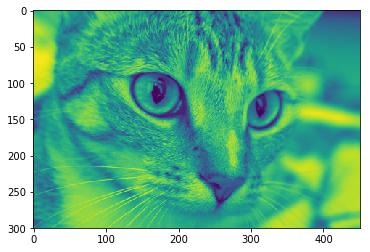

In [16]:

weights = np.array([[0.2126], [0.7152], [0.0722] ])
luminance = cat @ weights
plt.imshow(luminance.squeeze())



# Takeaways
- Think in **shapes**; many bugs are shape mismatches.
- Use **broadcasting** to avoid loops; prefer vectorized operations.
- In linear algebra, `@` is matrix product; `*` is elementwise.
- Prefer `solve`/`lstsq` to explicit inverses.
- Transpose/reshape change views of shape; they don’t alter the underlying values.
- Check dimensions early and often; write shapes next to symbols.